In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
bfs = pd.read_csv("/content/indian_roads_dataset.csv")

In [3]:
bfs.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


In [4]:
bfs.shape

(20000, 24)

In [5]:
bfs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_density    200

In [6]:
bfs.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


In [7]:
bfs.city.unique()

array(['Pune', 'Mumbai', 'Chandigarh', 'Chennai', 'Delhi', 'Bangalore',
       'Hyderabad', 'Kolkata'], dtype=object)

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Pune'),
  Text(1, 0, 'Mumbai'),
  Text(2, 0, 'Chandigarh'),
  Text(3, 0, 'Chennai'),
  Text(4, 0, 'Delhi'),
  Text(5, 0, 'Bangalore'),
  Text(6, 0, 'Hyderabad'),
  Text(7, 0, 'Kolkata')])

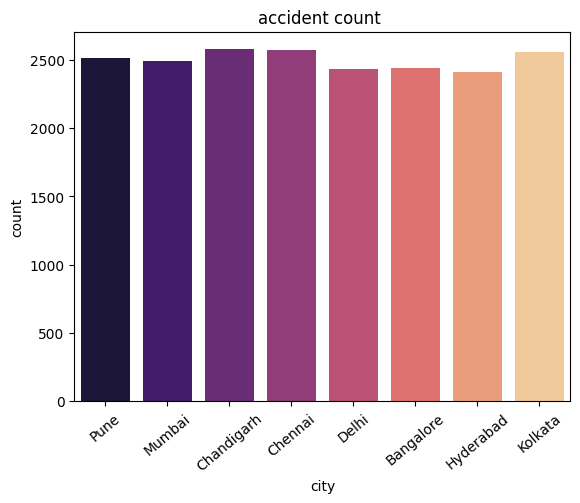

In [8]:
sns.countplot(x= bfs.city, palette='magma')
plt.title('accident count ')
plt.xticks(rotation=40)


In [9]:
bfs.accident_id.unique()

array([    0,     1,     2, ..., 19997, 19998, 19999])

how much of accident on each city

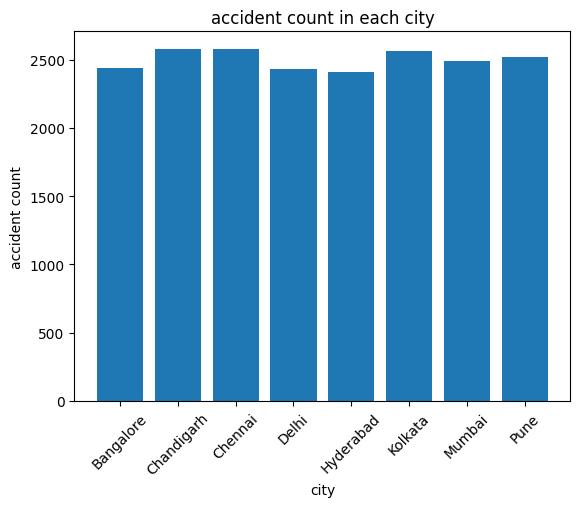

In [10]:
city_count=bfs.groupby('city')['accident_id'].count()
plt.bar(city_count.index,city_count.values)
plt.xlabel('city')
plt.ylabel('accident count')
plt.title('accident count in each city')
plt.xticks(rotation=45)
plt.show()

No of accident on week days

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Monday'),
  Text(1, 0, 'Friday'),
  Text(2, 0, 'Tuesday'),
  Text(3, 0, 'Saturday'),
  Text(4, 0, 'Sunday'),
  Text(5, 0, 'Thursday'),
  Text(6, 0, 'Wednesday')])

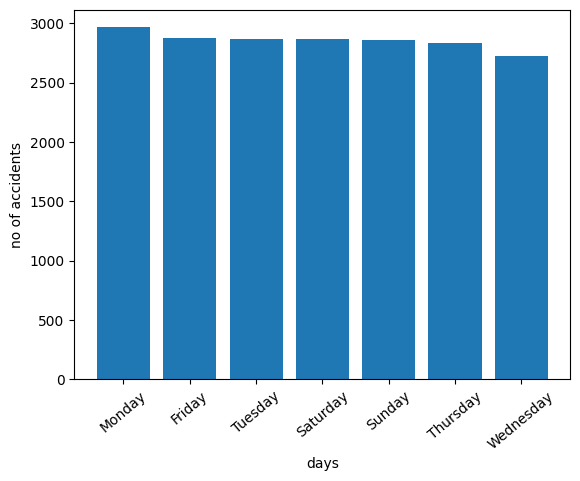

In [11]:
day_count=bfs['day_of_week'].value_counts()
plt.bar(day_count.index,day_count.values)
plt.xlabel('days')
plt.ylabel('no of accidents')
plt.xticks(rotation=40)

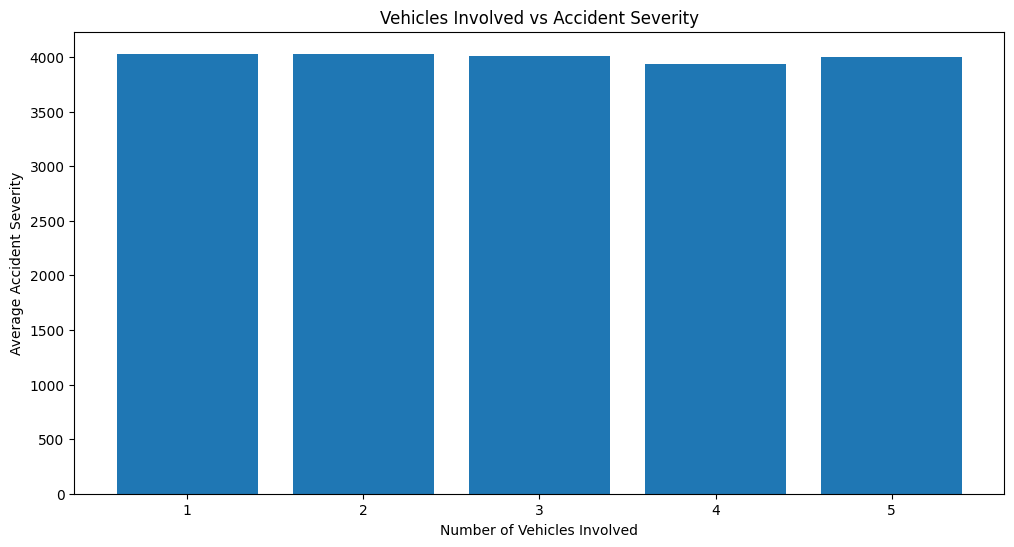

In [12]:
vehicle_severity = bfs.groupby('vehicles_involved')['accident_severity'].count()
vehicle_severity = vehicle_severity.sort_index()
plt.figure(figsize=(12,6))
plt.bar(vehicle_severity.index, vehicle_severity.values)

plt.xlabel("Number of Vehicles Involved")
plt.ylabel("Average Accident Severity")
plt.title("Vehicles Involved vs Accident Severity")

plt.show()

which traffic density level has the highest accidents

Text(0.5, 1.0, 'Accidents by Traffic Density')

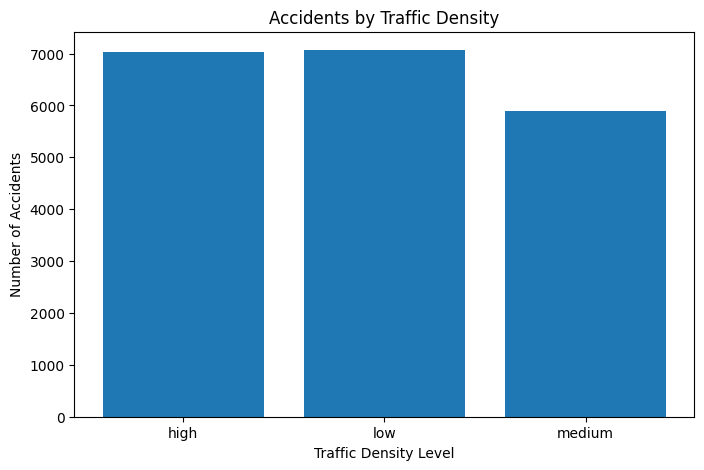

In [13]:
traffic_counts = bfs['traffic_density'].value_counts()
traffic_counts = traffic_counts.sort_index()

plt.figure(figsize=(8,5))
plt.bar(traffic_counts.index, traffic_counts.values)

plt.xlabel("Traffic Density Level")
plt.ylabel("Number of Accidents")
plt.title("Accidents by Traffic Density")

Does risk score increase on weekends?

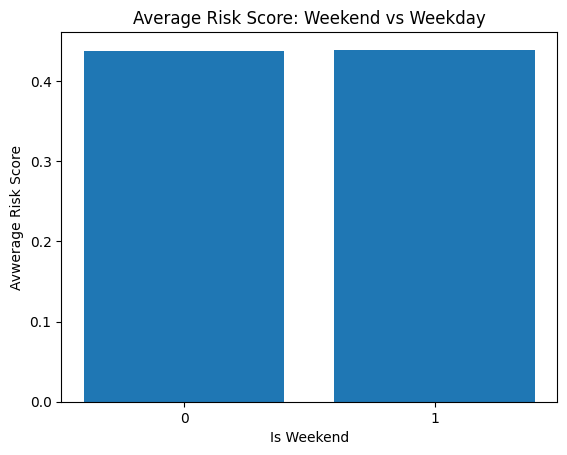

In [14]:
weekend_risk = bfs.groupby('is_weekend')['risk_score'].mean()

plt.bar(weekend_risk.index.astype(str), weekend_risk.values)

plt.xlabel("Is Weekend")
plt.ylabel("Avwerage Risk Score")
plt.title("Average Risk Score: Weekend vs Weekday")

plt.show()

Text(0.5, 0, 'Accident Severity')

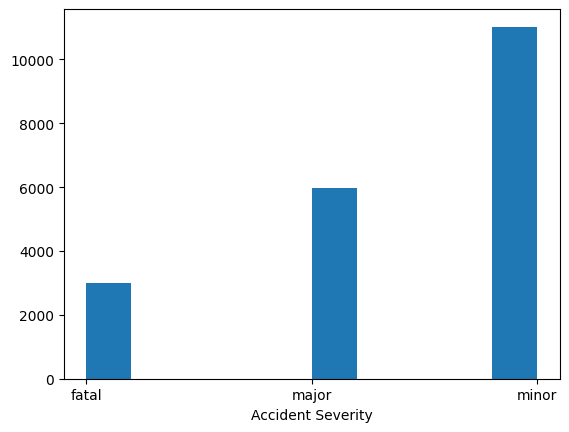

In [15]:
plt.hist(bfs['accident_severity'], bins=10, )
plt.xlabel('Accident Severity')

In [16]:
num_df = bfs.select_dtypes(include=np.number)
num_df

,accident_id,latitude,longitude,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,risk_score
0,0,18.680827,73.930388,5,1,3,1,32,2,2,0,0.85
1,1,18.817732,72.790846,4,1,4,0,34,4,3,0,0.10
2,2,19.096889,72.819424,13,0,3,0,21,1,1,0,0.45
3,3,30.787805,76.847507,11,1,1,1,30,5,2,0,0.65
4,4,12.965155,80.283313,16,0,3,1,24,2,1,0,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,13.092276,77.599571,3,0,1,1,31,3,2,0,0.10
19996,19996,13.172928,80.157062,1,1,1,1,20,4,2,0,0.10
19997,19997,12.997170,80.150724,15,1,3,0,22,3,3,0,0.10
19998,19998,22.454882,88.322213,4,1,3,1,33,1,0,0,0.10


In [17]:
corr = num_df.corr()
corr

,accident_id,latitude,longitude,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,risk_score
accident_id,1.000000,0.006247,0.002517,-0.005781,0.007213,-0.001911,-0.001411,-0.006716,-0.006733,-0.015964,-0.003335,-0.005487
latitude,0.006247,1.000000,0.009085,-0.000728,-0.002420,-0.007591,0.000194,-0.001549,-0.003700,-0.004742,-0.001618,0.001459
longitude,0.002517,0.009085,1.000000,-0.001834,-0.001751,0.003308,-0.003918,-0.007463,0.004330,0.007821,0.009107,-0.001439
hour,-0.005781,-0.000728,-0.001834,1.000000,-0.003763,0.000692,0.008689,-0.005982,-0.004176,-0.004320,0.172314,0.122017
is_weekend,0.007213,-0.002420,-0.001751,-0.003763,1.000000,0.009739,0.004062,-0.010849,0.006548,0.000931,0.002341,0.004033
lanes,-0.001911,-0.007591,0.003308,0.000692,0.009739,1.000000,-0.000646,-0.007051,0.002051,0.001189,0.006790,-0.001721
traffic_signal,-0.001411,0.000194,-0.003918,0.008689,0.004062,-0.000646,1.000000,0.004115,0.003319,0.013544,0.008051,0.001817
temperature,-0.006716,-0.001549,-0.007463,-0.005982,-0.010849,-0.007051,0.004115,1.000000,-0.004479,-0.005842,-0.012589,-0.001885
vehicles_involved,-0.006733,-0.003700,0.004330,-0.004176,0.006548,0.002051,0.003319,-0.004479,1.000000,0.550966,0.002094,0.000642
casualties,-0.015964,-0.004742,0.007821,-0.004320,0.000931,0.001189,0.013544,-0.005842,0.550966,1.000000,0.003854,0.119954


<Axes: >

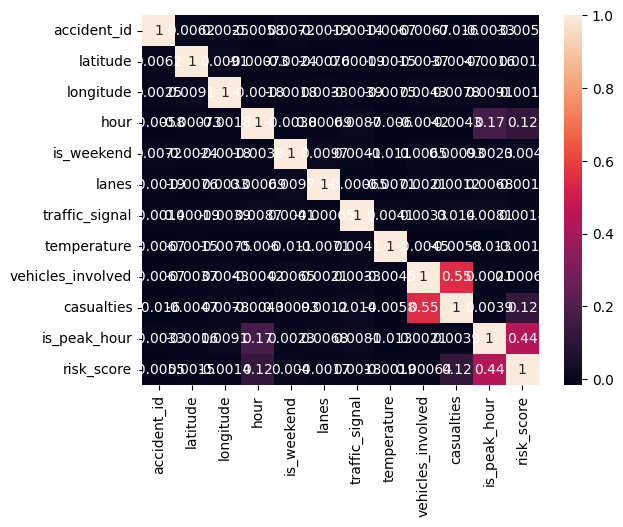

In [18]:
sns.heatmap(corr,annot=True)